In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"]=(12, 5)
plt.rcParams["font.size"]=12

In [16]:
## Load Cleaned dataset
df=pd.read_csv(r"C:\Users\hites\Downloads\Superstore_cleaned.csv")
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Profit Margin %,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,11.25,7


In [17]:
# Convert date back to datetime
df["Order Date"]=pd.to_datetime(df["Order Date"])
df["Ship Date"]=pd.to_datetime(df["Ship Date"])

In [18]:
df.shape

(9994, 26)

In [19]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Profit Margin %,Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136,2016,11,November,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820,2016,11,November,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714,2016,6,June,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310,2015,10,October,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164,2015,10,October,11.25,7


### Most Imp Business Question

#### Q1. Yearly Sales and Profit Trend

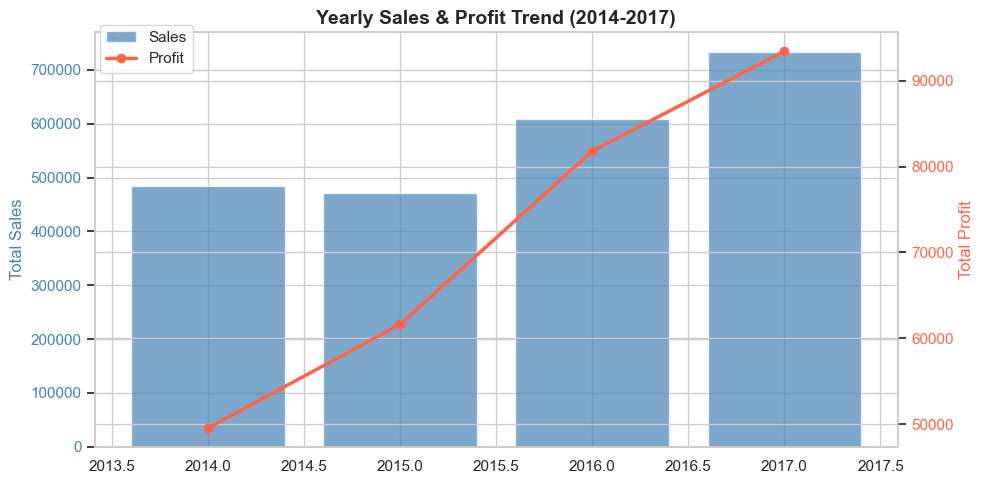

   Order Year        Sales      Profit
0        2014  484247.4981  49543.9741
1        2015  470532.5090  61618.6037
2        2016  609205.5980  81795.1743
3        2017  733215.2552  93439.2696


In [20]:
# Grp by yr & sum sales and profit
yearly=df.groupby("Order Year")[["Sales", "Profit"]].sum().reset_index()
fig, ax1=plt.subplots(figsize=(10,5))

# Bar chart for sales
bars=ax1.bar(yearly["Order Year"], yearly["Sales"], color="steelblue", alpha=0.7, label="Sales")
ax1.set_ylabel("Total Sales", color="steelblue")
ax1.tick_params(axis="y", labelcolor="steelblue")

# Line chart for profit
ax2=ax1.twinx()
ax2.plot(yearly["Order Year"], yearly["Profit"], color="tomato", marker="o", linewidth=2.5, label="Profit")
ax2.set_ylabel("Total Profit", color="tomato")
ax2.tick_params(axis="y", labelcolor="tomato")

plt.title("Yearly Sales & Profit Trend (2014-2017)", fontsize=14, fontweight="bold")
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.95))
plt.tight_layout()
plt.savefig("Yearly_trend.png", dpi=150)
plt.show()

print(yearly)

#### Q2. Monthly Sales Pattern (Seasonality)

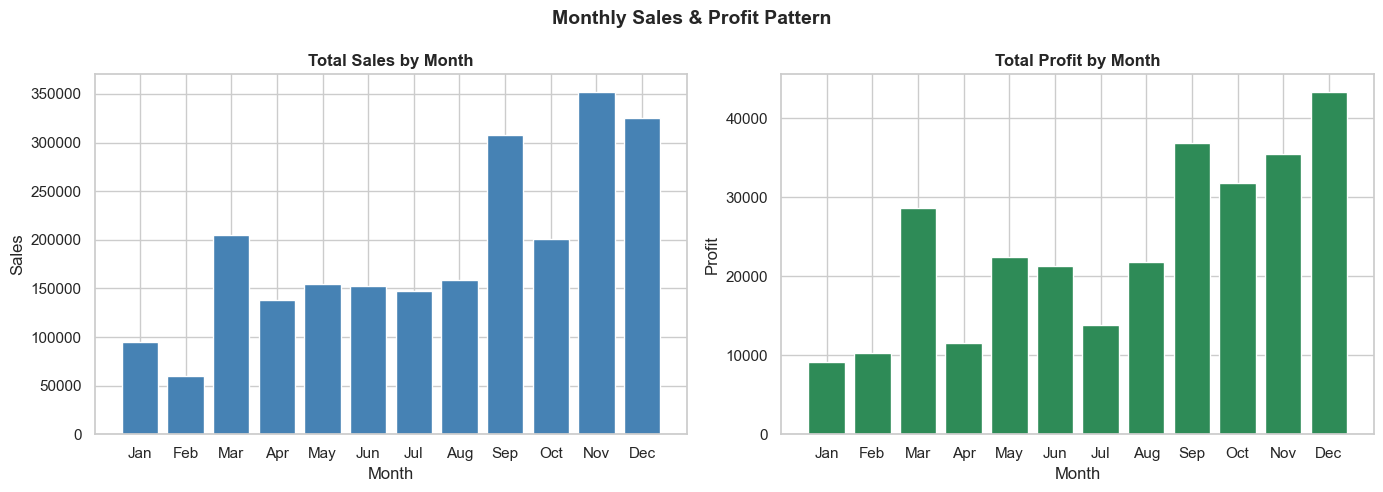

In [21]:
# Avg sales by month across all years
monthly=df.groupby("Order Month")[["Sales", "Profit"]].sum().reset_index()

# X-axis month names
month_names=["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
fig, axes=plt.subplots(1,2,figsize=(14,5))

# Sales by month
axes[0].bar(month_names, monthly["Sales"], color="steelblue")
axes[0].set_title("Total Sales by Month", fontweight="bold")
axes[0].set_ylabel("Sales")
axes[0].set_xlabel("Month")

# Profit by month
axes[1].bar(month_names, monthly["Profit"], color="seagreen")
axes[1].set_title("Total Profit by Month", fontweight="bold")
axes[1].set_ylabel("Profit")
axes[1].set_xlabel("Month")

plt.suptitle("Monthly Sales & Profit Pattern", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Monthly_pattern.png", dpi=150)
plt.show()

#### Q3. Category & Sub-category Profitability

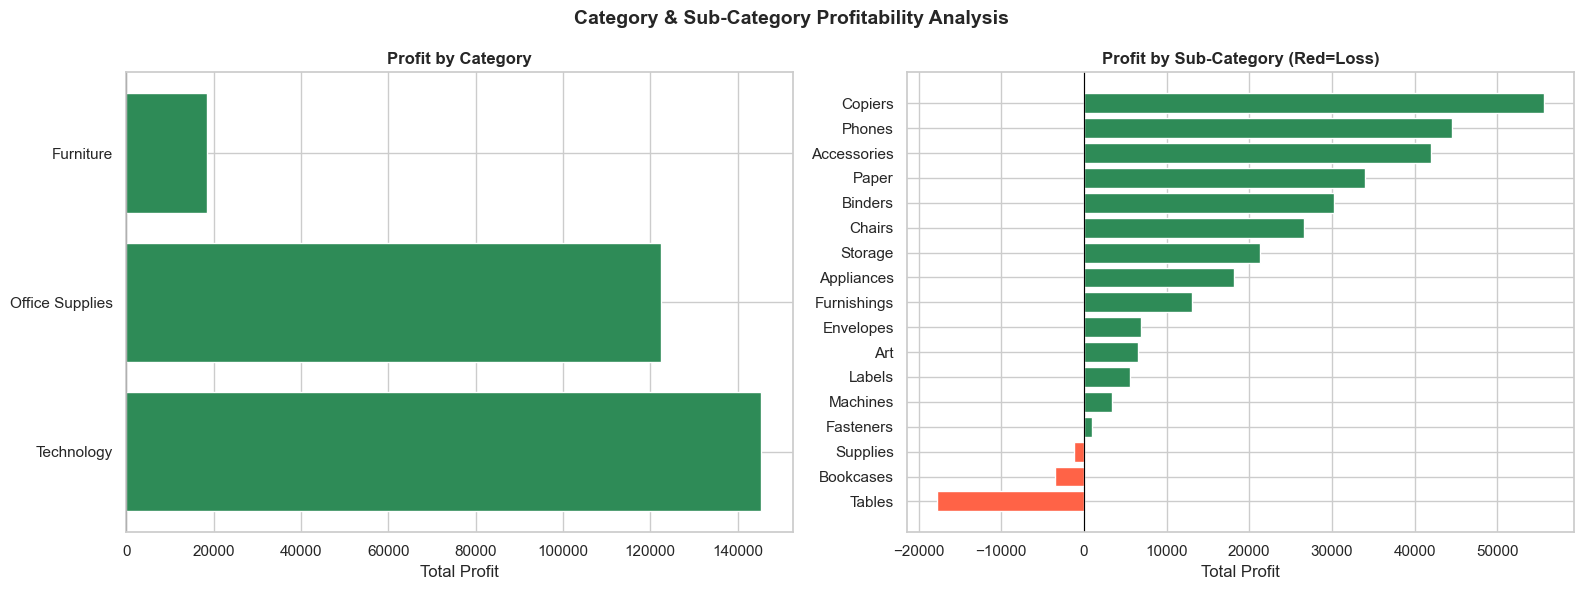


Sub-Categories making a LOSS:
   Sub-Category      Profit
16       Tables -17725.4811
4     Bookcases  -3472.5560
15     Supplies  -1189.0995


In [22]:
# Profit by category
cat_profit=df.groupby("Category")["Profit"].sum().reset_index().sort_values("Profit", ascending=False)

# Profit by sub-category
subcat_profit=df.groupby("Sub-Category")["Profit"].sum().reset_index().sort_values("Profit", ascending=True)
fig,axes=plt.subplots(1,2,figsize=(16,6))

# Cat
colors=["seagreen" if x>0 else "tomato" for x in cat_profit["Profit"]]
axes[0].barh(cat_profit["Category"], cat_profit["Profit"], color=colors)
axes[0].set_title("Profit by Category", fontweight="bold")
axes[0].set_xlabel("Total Profit")
axes[0].axvline(0, color="black", linewidth=0.8)

# Sub-cat
colors2=["seagreen" if x>0 else "tomato" for x in subcat_profit["Profit"]]
axes[1].barh(subcat_profit["Sub-Category"], subcat_profit["Profit"], color=colors2)
axes[1].set_title("Profit by Sub-Category (Red=Loss)", fontweight="bold")
axes[1].set_xlabel("Total Profit")
axes[1].axvline(0, color="black", linewidth=0.8)

plt.suptitle("Category & Sub-Category Profitability Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Category_profit.png", dpi=150)
plt.show()

print("\nSub-Categories making a LOSS:")
print(subcat_profit[subcat_profit["Profit"]<0])

#### Q4. Discount vs Profit

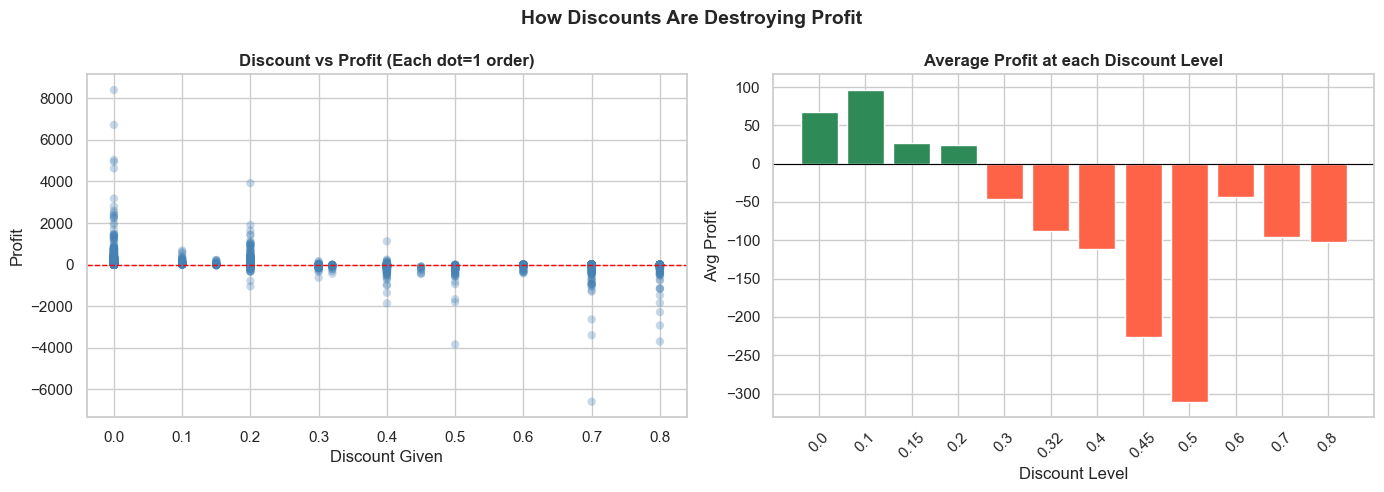

Avg profit with No discount:  66.9
Avg profit with 50%+ discount:  -105.28


In [23]:
fig,axes=plt.subplots(1,2,figsize=(14,5))

# Scatter plot
axes[0].scatter(df["Discount"], df["Profit"], alpha=0.3, color="steelblue", edgecolors="none")
axes[0].axhline(0, color="red", linestyle="--", linewidth=1)
axes[0].set_title("Discount vs Profit (Each dot=1 order)", fontweight="bold")
axes[0].set_xlabel("Discount Given")
axes[0].set_ylabel("Profit")

# Avg profit at each discount level
disc_profit=df.groupby("Discount")["Profit"].mean().reset_index()
axes[1].bar(disc_profit["Discount"].astype(str), disc_profit["Profit"], color=["seagreen" if x>0 else "tomato" for x in disc_profit["Profit"]])
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_title("Average Profit at each Discount Level", fontweight="bold")
axes[1].set_xlabel("Discount Level")
axes[1].set_ylabel("Avg Profit")
axes[1].tick_params(axis="x", rotation=45)

plt.suptitle("How Discounts Are Destroying Profit", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Discount_vs_Profit.png", dpi=150)
plt.show()

print("Avg profit with No discount: ", round(df[df["Discount"]==0]["Profit"].mean(),2))
print("Avg profit with 50%+ discount: ", round(df[df["Discount"]>=0.5]["Profit"].mean(),2))

#### Q5. Regional Performance

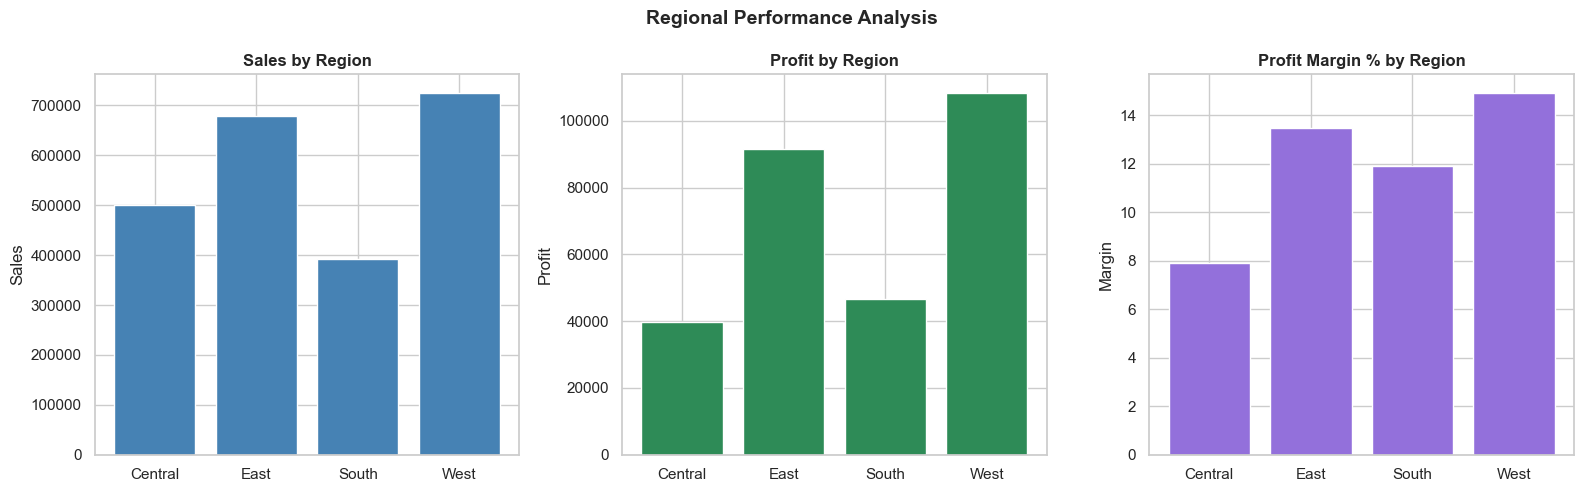

    Region        Sales       Profit  Profit Margin
0  Central  501239.8908   39706.3625           7.92
1     East  678781.2400   91522.7800          13.48
2    South  391721.9050   46749.4303          11.93
3     West  725457.8245  108418.4489          14.94


In [26]:
region=df.groupby("Region")[["Sales", "Profit"]].sum().reset_index()
region["Profit Margin"]=(region["Profit"]/region["Sales"]*100).round(2)
fig,axes=plt.subplots(1,3,figsize=(16,5))

axes[0].bar(region["Region"], region["Sales"], color="steelblue")
axes[0].set_title("Sales by Region", fontweight="bold")
axes[0].set_ylabel("Sales")

axes[1].bar(region["Region"], region["Profit"], color=["seagreen" if x>0 else "tomato" for x in region["Profit"]])
axes[1].set_title("Profit by Region", fontweight="bold")
axes[1].set_ylabel("Profit")

axes[2].bar(region["Region"], region["Profit Margin"], color="mediumpurple")
axes[2].set_title("Profit Margin % by Region", fontweight="bold")
axes[2].set_ylabel("Margin")

plt.suptitle("Regional Performance Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Regional_performance.png", dpi=150)
plt.show()

print(region)

#### Q6. Customer Segment Analysis

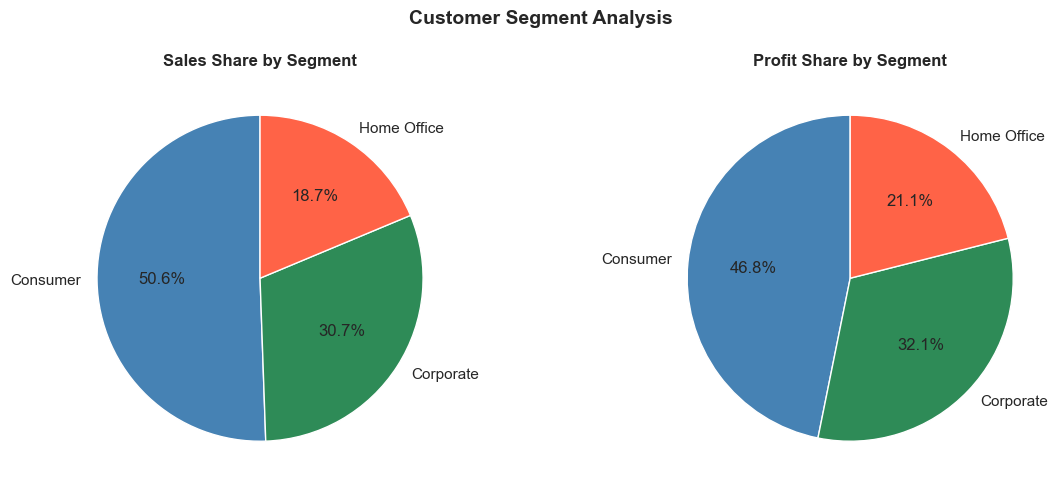

       Segment         Sales       Profit
0     Consumer  1.161401e+06  134119.2092
1    Corporate  7.061464e+05   91979.1340
2  Home Office  4.296531e+05   60298.6785


In [25]:
segment=df.groupby("Segment")[["Sales", "Profit"]].sum().reset_index()
fig,axes=plt.subplots(1,2,figsize=(12,5))

axes[0].pie(segment["Sales"], labels=segment["Segment"], autopct="%1.1f%%", colors=["steelblue", "seagreen", "tomato"], startangle=90)
axes[0].set_title("Sales Share by Segment", fontweight="bold")

axes[1].pie(segment["Profit"], labels=segment["Segment"], autopct="%1.1f%%", colors=["steelblue", "seagreen", "tomato"], startangle=90)
axes[1].set_title("Profit Share by Segment", fontweight="bold")

plt.suptitle("Customer Segment Analysis", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Segment_analysis.png", dpi=150)
plt.show()
print(segment)

#### Q7. Top 10 customers by profit

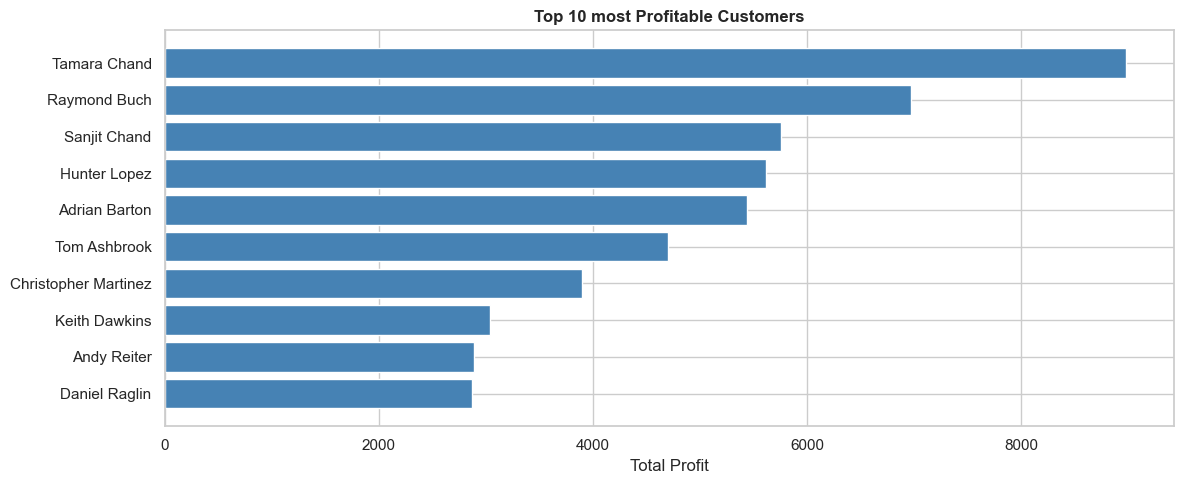

            Customer Name     Profit
730          Tamara Chand  8981.3239
622          Raymond Buch  6976.0959
671          Sanjit Chand  5757.4119
334          Hunter Lopez  5622.4292
6           Adrian Barton  5444.8055
757          Tom Ashbrook  4703.7883
157  Christopher Martinez  3899.8904
431         Keith Dawkins  3038.6254
35            Andy Reiter  2884.6208
194         Daniel Raglin  2869.0760


In [27]:
top_customers=df.groupby("Customer Name")["Profit"].sum().reset_index()
top_customers=top_customers.sort_values("Profit", ascending=False).head(10)

plt.figure(figsize=(12,5))
bars=plt.barh(top_customers["Customer Name"], top_customers["Profit"], color="steelblue")
plt.xlabel("Total Profit")
plt.title("Top 10 most Profitable Customers", fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig("Top_customers.png", dpi=150)
plt.show()
print(top_customers)

#### Q8. Shipping Mode vs Profit

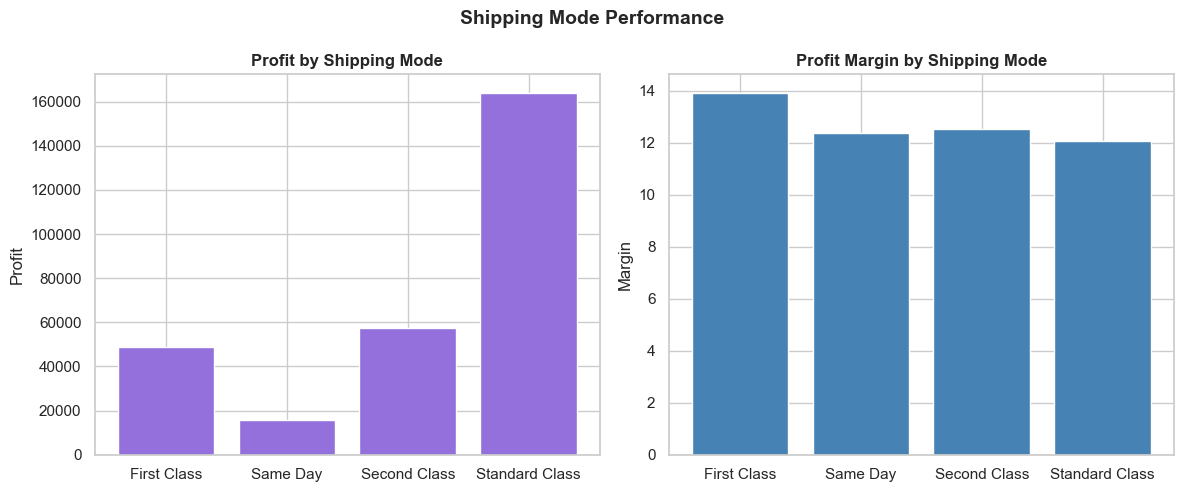

        Ship Mode         Sales       Profit  Profit Margin
0     First Class  3.514284e+05   48969.8399          13.93
1        Same Day  1.283631e+05   15891.7589          12.38
2    Second Class  4.591936e+05   57446.6354          12.51
3  Standard Class  1.358216e+06  164088.7875          12.08


In [28]:
ship=df.groupby("Ship Mode")[["Sales", "Profit"]].sum().reset_index()
ship["Profit Margin"]=(ship["Profit"]/ship["Sales"]*100).round(2)
fig,axes=plt.subplots(1,2,figsize=(12,5))

axes[0].bar(ship["Ship Mode"], ship["Profit"], color="mediumpurple")
axes[0].set_title("Profit by Shipping Mode", fontweight="bold")
axes[0].set_ylabel("Profit")

axes[1].bar(ship["Ship Mode"], ship["Profit Margin"], color="steelblue")
axes[1].set_title("Profit Margin by Shipping Mode", fontweight="bold")
axes[1].set_ylabel("Margin")

plt.suptitle("Shipping Mode Performance", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("Shipping_mode.png", dpi=150)
plt.show()
print(ship)

### Summary

- Sales grow every year but profit margin stays thin. Revenue ≠ Profit.
- November and December are peak months.
- Tables, Bookcases, Supplies sub-categories make a LOSS.
- Orders with 50%+ discount make negative profit on average.
- West region has highest sales and highest profit margin(14.94%).
- Central region has the lowest margin(7.92%) despite decent sales—indicating a profitability problem in the central region.
- Consumer segment brings most revenue.
- Top 10 customers contribute disproportionate profit.
- Same Day shipping has lowest profit margin.